# Night acoustics — baseline & anomaly investigation

Interactive workbench for the night-noise alert. Tweak the knobs in the params cell and re-run.

**Candidate rule:** night noise > `baseline + SIGMA·std`, sustained ≥ `MIN_MINUTES` → alert.

Data: `audio_noise` for house1 (dumped by `analysis/dump_audio_noise.ts`). `noise_db_mean` is
relative **dBFS** (higher = louder, 0 = loudest). Times shown in **SAST** (UTC+2).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (13, 4.5)

# ── knobs — change these and re-run ──────────────────────────────────────────
SAST_OFFSET_H = 2
NIGHT_START, NIGHT_END = 20, 5      # SAST hours counted as "night" (20:00–05:00)
SIGMA = 2.0                         # threshold = baseline + SIGMA·std
MIN_MINUTES = 2.0                   # elevated must persist at least this long
import os
CSV = next(p for p in ["audio_noise.csv", "analysis/audio_noise.csv"] if os.path.exists(p))  # works from either dir

In [2]:
df = pd.read_csv(CSV, parse_dates=["time"])
df = df.dropna(subset=["noise_db_mean"]).sort_values("time").reset_index(drop=True)
df["t_sast"] = df["time"] + pd.Timedelta(hours=SAST_OFFSET_H)
df["hour"] = df["t_sast"].dt.hour
df["is_night"] = (df["hour"] >= NIGHT_START) | (df["hour"] < NIGHT_END)
df["night_date"] = (df["t_sast"] - pd.Timedelta(hours=NIGHT_START)).dt.normalize()
df.loc[~df["is_night"], "night_date"] = pd.NaT
n_nights = int(df["night_date"].nunique())
print(f"{len(df)} points   {df['time'].min()} → {df['time'].max()}")
print(f"night points: {int(df['is_night'].sum())}   over {n_nights} nights")

24433 points   2026-07-27 20:01:35+00:00 → 2026-08-15 16:18:00.551000+00:00
night points: 9029   over 18 nights


In [3]:
# Sampling cadence — "sustained ≥ 2 min" only means something relative to how often a point arrives.
gaps = df["time"].diff().dt.total_seconds().dropna()
print(f"sampling gap:  median {gaps.median():.0f}s   p90 {gaps.quantile(.9):.0f}s   max {gaps.max():.0f}s")

sampling gap:  median 60s   p90 60s   max 67123s


night baseline = -41.04 dBFS    std = 5.53 dB    +2σ threshold = -29.98 dBFS


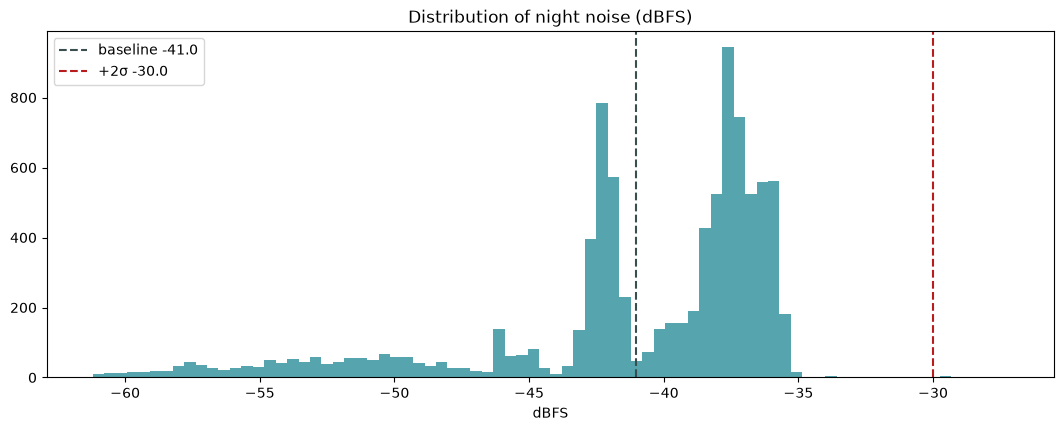

In [4]:
# Night baseline + std, and the threshold.
night = df[df["is_night"]]
baseline = night["noise_db_mean"].mean()
std = night["noise_db_mean"].std()
thr = baseline + SIGMA * std
print(f"night baseline = {baseline:.2f} dBFS    std = {std:.2f} dB    +{SIGMA:g}σ threshold = {thr:.2f} dBFS")

# distribution of night noise, with baseline & threshold marked
fig, ax = plt.subplots()
ax.hist(night["noise_db_mean"], bins=80, color="#2A8E9A", alpha=.8)
ax.axvline(baseline, color="#3a4d4f", ls="--", lw=1.5, label=f"baseline {baseline:.1f}")
ax.axvline(thr, color="#B91C1C", ls="--", lw=1.5, label=f"+{SIGMA:g}σ {thr:.1f}")
ax.set_title("Distribution of night noise (dBFS)"); ax.set_xlabel("dBFS"); ax.legend()
plt.show()

In [5]:
# Backtest: flag night points above threshold, group consecutive-in-time points into events.
df["above"] = df["is_night"] & (df["noise_db_mean"] > thr)
df["grp"] = (df["above"] != df["above"].shift()).cumsum()
rows = []
for _, g in df[df["above"]].groupby("grp"):
    s, e = g["time"].iloc[0], g["time"].iloc[-1]
    rows.append({"start_SAST": (s + pd.Timedelta(hours=SAST_OFFSET_H)),
                 "dur_min": round((e - s).total_seconds() / 60, 1),
                 "n_pts": len(g), "peak_db": round(g["noise_db_mean"].max(), 1),
                 "night_date": g["night_date"].iloc[0]})
ev = pd.DataFrame(rows)
sustained = ev[ev["dur_min"] >= MIN_MINUTES].copy() if len(ev) else ev
print(f"above-threshold night points: {int(df['above'].sum())} / {int(df['is_night'].sum())}")
print(f"events (runs): {len(ev)}   |   sustained ≥ {MIN_MINUTES:g} min: {len(sustained)}"
      f"   →   {len(sustained)/max(1,n_nights):.2f} per night")
sustained.sort_values("start_SAST")[["start_SAST", "dur_min", "n_pts", "peak_db"]]

above-threshold night points: 10 / 9029
events (runs): 4   |   sustained ≥ 2 min: 1   →   0.06 per night


,start_SAST,dur_min,n_pts,peak_db
1,2026-08-09 01:27:37.351000+00:00,3.0,4,-28.6


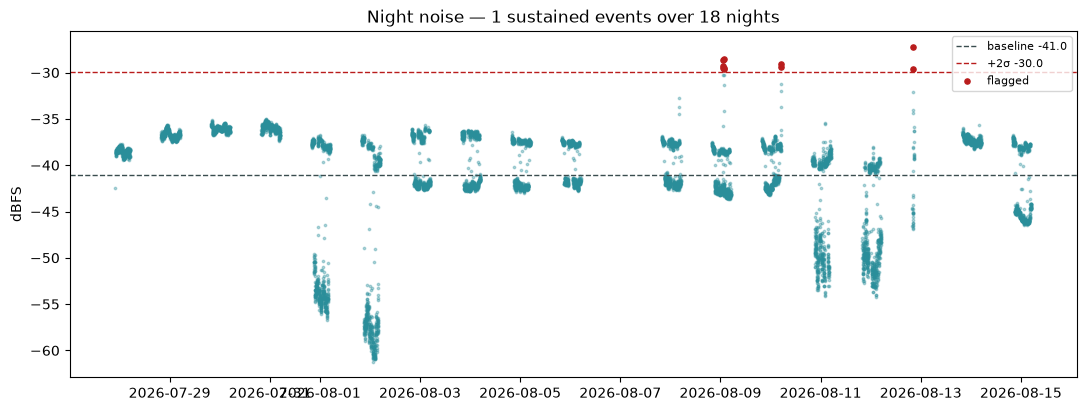

In [6]:
# Full-period night noise with threshold + flags.
fig, ax = plt.subplots()
nt = df[df["is_night"]]
ax.scatter(nt["t_sast"], nt["noise_db_mean"], s=3, c="#2A8E9A", alpha=.35)
ax.axhline(baseline, color="#3a4d4f", ls="--", lw=1, label=f"baseline {baseline:.1f}")
ax.axhline(thr, color="#B91C1C", ls="--", lw=1, label=f"+{SIGMA:g}σ {thr:.1f}")
ax.scatter(df[df["above"]]["t_sast"], df[df["above"]]["noise_db_mean"], s=14, c="#B91C1C", label="flagged")
ax.set_title(f"Night noise — {len(sustained)} sustained events over {n_nights} nights")
ax.set_ylabel("dBFS"); ax.legend(loc="upper right", fontsize=8)
plt.show()

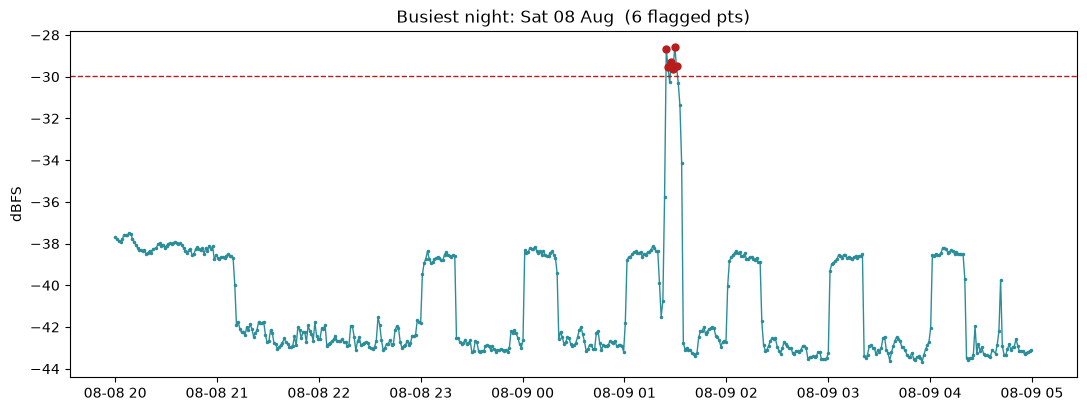

In [7]:
# Zoom on the busiest night (whichever had the most flagged points).
flagged_nights = df.loc[df["above"], "night_date"].value_counts()
if len(flagged_nights):
    tn = flagged_nights.idxmax()
    seg = df[df["night_date"] == tn]
    fig, ax = plt.subplots()
    ax.plot(seg["t_sast"], seg["noise_db_mean"], color="#2A8E9A", lw=1, marker=".", ms=3)
    ax.axhline(thr, color="#B91C1C", ls="--", lw=1)
    ax.scatter(seg[seg["above"]]["t_sast"], seg[seg["above"]]["noise_db_mean"], s=25, c="#B91C1C", zorder=3)
    ax.set_title(f"Busiest night: {pd.Timestamp(tn):%a %d %b}  ({int(flagged_nights.max())} flagged pts)")
    ax.set_ylabel("dBFS")
    plt.show()
else:
    print("no flagged points at these settings")

In [8]:
# Sensitivity sweep — how the event count moves with SIGMA × min-duration. Use it to pick the line.
def count_events(sigma, min_min):
    t = baseline + sigma * std
    above = df["is_night"] & (df["noise_db_mean"] > t)
    grp = (above != above.shift()).cumsum()
    n = 0
    for _, g in df[above].groupby(grp):
        if (g["time"].iloc[-1] - g["time"].iloc[0]).total_seconds() / 60 >= min_min:
            n += 1
    return n

SIGMAS = [1.0, 1.5, 1.75, 2.0, 2.5, 3.0]
MINS = [0, 2, 5, 10]
sweep = pd.DataFrame({f"{m}min": [count_events(s, m) for s in SIGMAS] for m in MINS},
                     index=[f"{s}σ" for s in SIGMAS])
print(f"events over {n_nights} nights (divide by {n_nights} for per-night):")
sweep

events over 18 nights (divide by 18 for per-night):


,0min,2min,5min,10min
1.0σ,30,11,5,0
1.5σ,3,3,1,0
1.75σ,3,2,1,0
2.0σ,4,1,0,0
2.5σ,1,0,0,0
3.0σ,0,0,0,0


### How to use this
- The **baseline/std** are solid from this much data — a few nights already pin them.
- Pick **SIGMA** and **MIN_MINUTES** in the params cell from the sweep + how the flagged events
  look in the plots, then re-run.
- Refinements to try: **median + MAD** instead of mean/std (steadier vs spikes), a **per-night /
  rolling** baseline, and **subtracting the fan-noise baseline** to isolate true *bird* noise.